#### Generate toy dataset

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from random import randint, choice
 
IMG_SIZE = 128
NUM_IMAGES = 1000
NUM_CLASSES = 3
NUM_PROPOSALS = 20
NUM_ITERATIONS = 3
HIDDEN_DIM = 256
SHAPE_LABELS = {'circle': 1, 'square': 2, 'triangle': 3}
CLASS_NAMES = {1: 'circle', 2: 'square', 3: 'triangle'}
COLORS = {1: 'red', 2: 'green', 3: 'blue'}


def draw_circle(img, x, y, size):
    cx, cy = x + size//2, y + size//2
    r = size//2
    for i in range(y, min(y+size, IMG_SIZE)):
        for j in range(x, min(x+size, IMG_SIZE)):
            if (i-cy)**2 + (j-cx)**2 <= r**2:
                img[i, j] = 255
    return img

def draw_square(img, x, y, size):
    img[y:min(y+size, IMG_SIZE), x:min(x+size, IMG_SIZE)] = 255
    return img

def draw_triangle(img, x, y, size):
    
    def area(a, b, c):
        return abs((b[0]-a[0])*(c[1]-a[1]) - (c[0]-a[0])*(b[1]-a[1])) / 2
    
    p1 = np.array([x + size//2, y])
    p2 = np.array([x, y + size])
    p3 = np.array([x + size, y + size])
    
    min_x = max(0, int(min(p1[0], p2[0], p3[0])))
    max_x = min(IMG_SIZE, int(max(p1[0], p2[0], p3[0])) + 1)
    min_y = max(0, int(min(p1[1], p2[1], p3[1])))
    max_y = min(IMG_SIZE, int(max(p1[1], p2[1], p3[1])) + 1)
    
    total_area = area(p1, p2, p3)
    
    for i in range(min_y, max_y):
        for j in range(min_x, max_x):
            p = np.array([j, i])
            a1 = area(p, p2, p3)
            a2 = area(p1, p, p3)
            a3 = area(p1, p2, p)
            if abs(total_area - (a1 + a2 + a3)) < 1e-6:
                img[i, j] = 255
    return img

def check_overlap(b1, b2):
    x1, y1, w1, h1 = b1
    x2, y2, w2, h2 = b2
    xi1, yi1 = max(x1, x2), max(y1, y2)
    xi2, yi2 = min(x1+w1, x2+w2), min(y1+h1, y2+h2)
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    area1, area2 = w1*h1, w2*h2
    iou = inter / (area1 + area2 - inter) if (area1 + area2 - inter) > 0 else 0
    return iou > 0.1

def draw_shape_on_image(img, shape, size, x, y):
    if shape == 'circle':
        img = draw_circle(img, x, y, size)
    elif shape == 'square':
        img = draw_square(img, x, y, size)
    elif shape == 'triangle':
        img = draw_triangle(img, x, y, size)
    return img

def create_dataset():
    dataset = []
    for _ in range(NUM_IMAGES):
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        num_shapes = randint(1, 3)
        shapes_info = []
        bboxes = []
        
        for __ in range(num_shapes):
            for attempt in range(30):
                shape = choice(list(SHAPE_LABELS.keys()))
                size = randint(15, 40)
                x = randint(10, IMG_SIZE - size - 10)
                y = randint(10, IMG_SIZE - size - 10)
                new_bbox = [x, y, size, size]
                
                overlap = False
                for b in bboxes:
                    if check_overlap(new_bbox, b):
                        overlap = True
                        break
                
                if not overlap:
                    img = draw_shape_on_image(img, shape, size, x, y)
                    
                    shapes_info.append({
                        'bbox': new_bbox,
                        'label': SHAPE_LABELS[shape],
                        'type': shape
                    })
                    bboxes.append(new_bbox)
                    break
        
        dataset.append({'image': img, 'shapes': shapes_info})
    return dataset

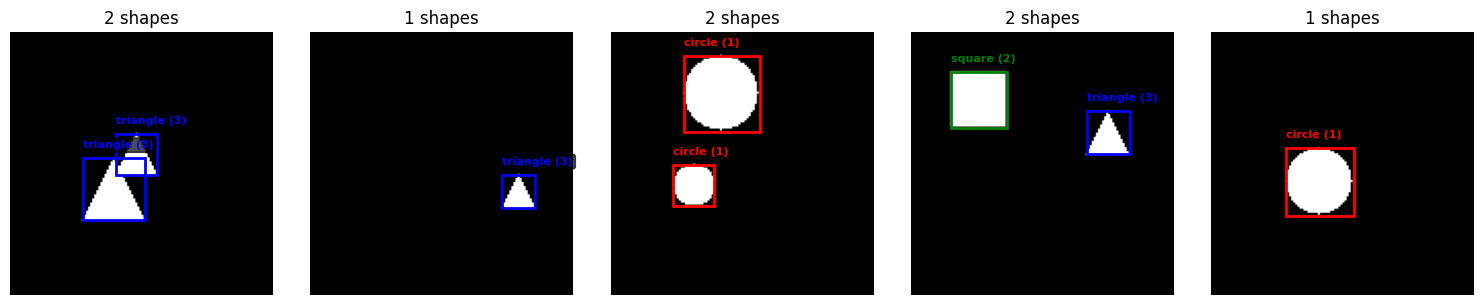

Total images: 1000
Total shapes: 2002
Avg shapes/image: 2.00


In [84]:
dataset = create_dataset()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
colors = {'circle': 'red', 'square': 'green', 'triangle': 'blue'}

for i in range(5):
    img = dataset[i]['image']
    img_rgb = np.stack([img, img, img], axis=2)
    axes[i].imshow(img_rgb)
    
    for shape in dataset[i]['shapes']:
        x, y, w, h = shape['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, 
                                edgecolor=colors[shape['type']], facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(x, y-5, f"{shape['type']} ({shape['label']})", 
                    color=colors[shape['type']], fontsize=8, weight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7))
    
    axes[i].set_title(f'{len(dataset[i]["shapes"])} shapes')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"Total images: {len(dataset)}")
total_shapes = sum(len(s['shapes']) for s in dataset)
print(f"Total shapes: {total_shapes}")
print(f"Avg shapes/image: {total_shapes/len(dataset):.2f}")

##### Prepare dataset for model

In [85]:
DATA_SPLIT_RATIO = 0.9
NUM_TRAIN_DATA = int(DATA_SPLIT_RATIO * NUM_IMAGES)
X_train, X_test, y_train, y_test = list(), list() , list(), list()

for i in range(NUM_TRAIN_DATA):
    X_train.append(dataset[i]["image"])
    y_train.append(dataset[i]["shapes"])

for i in range(NUM_TRAIN_DATA , NUM_IMAGES):
    X_test.append(dataset[i]["image"])
    y_test.append(dataset[i]["shapes"])


In [86]:
import torch
from torch.utils.data import DataLoader, Dataset

device = torch.device('cpu' if torch.mps.is_available() else 'cpu')

class ImgDataset(Dataset):
    def __init__(self, features_list: list[dict], labels_list: list[dict]): 
        self.features = features_list
        self.labels = labels_list

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype = torch.float32)
        y = []
        for shape in self.labels[idx]:
            bbox = shape['bbox']
            label = shape['label']
            y.append({
                'boxes': torch.tensor(bbox, dtype=torch.float32),
                'labels': torch.tensor([label], dtype=torch.int64)
            })
        return x, y
    
def collate_fn(batch):
    images = []
    all_targets = []
    
    for img, targets in batch:
        images.append(img)
        all_targets.append(targets)
    
    images = torch.stack(images, 0)
    return images, all_targets

In [87]:
train_dataset = ImgDataset(X_train, y_train)
test_dataset = ImgDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size= 16, shuffle= True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size= 16, shuffle= True , collate_fn=collate_fn)

##### Implement spase RCNN

In [88]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import roi_align
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class DynamicInteractiveHead(nn.Module):
    def __init__(self, in_channels: int, hidden_dim: int, num_classes: int, roi_output_size: tuple):

        super().__init__()
    
        self.roi_output_size = roi_output_size
        self.in_channels = in_channels
        self.hidden_dim = hidden_dim
    
        flattened_size = in_channels * roi_output_size[0] * roi_output_size[1]
        self.weight_generator = nn.Linear(hidden_dim, flattened_size)
        
        self.classifier = nn.Sequential(
            nn.Linear(flattened_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes + 1) 
        )
        
        self.box_regressor = nn.Sequential(
            nn.Linear(flattened_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4)
        )
    
    def forward(self, roi_features: torch.Tensor, proposal_features: torch.Tensor):
        batch_size, num_proposals, channels, height, width = roi_features.shape
        flattened_roi_features = roi_features.view(batch_size, num_proposals, channels * height * width)
        interaction_weights = self.weight_generator(proposal_features)
        interacted_features = flattened_roi_features * torch.sigmoid(interaction_weights)
        class_logits = self.classifier(interacted_features)
        bbox_deltas = self.box_regressor(interacted_features)
        
        return class_logits, bbox_deltas

In [89]:
class Sparse_RCNN(nn.Module):
    def __init__(self, in_channel=1, out_channel=128, 
                num_proposals=20, num_features=256,
                num_classes=3, img_size=128, num_iterations=3):
        super().__init__()

        self.img_size = img_size
        self.num_proposals = num_proposals
        self.num_classes = num_classes
        self.num_iterations = num_iterations

        self.backbone = nn.Sequential(
            nn.Conv2d(in_channel, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2)
        )

        self.proposal_boxes = nn.Parameter(torch.rand(num_proposals, 4) * (IMG_SIZE / 2))
        self.proposal_features = nn.Parameter(torch.randn(num_proposals, num_features))

        self.stride = 8
        self.spatial_scale = 1.0 / self.stride
        self.roi_output_size = (7, 7)
        self.sampling_ratio = -1

        self.dynamic_heads = nn.ModuleList([
            DynamicInteractiveHead(
                in_channels=out_channel,
                hidden_dim=num_features,
                num_classes=num_classes,
                roi_output_size=self.roi_output_size
            ) for _ in range(num_iterations)
        ])

    def forward(self, x):
        if len(x.shape) == 3:
            x = x.unsqueeze(1)
        
        feature_map = self.backbone(x)
        
        batch_size = feature_map.shape[0]
        device = feature_map.device
        
        boxes = self.proposal_boxes.unsqueeze(0).expand(batch_size, -1, -1)
        proposal_feats = self.proposal_features.unsqueeze(0).expand(batch_size, -1, -1)
        
        for stage in range(self.num_iterations):
            boxes = self._clamp_boxes(boxes)
            boxes_xyxy = self._convert_xywh_to_xyxy(boxes)
            roi_features = self._apply_roi_align(feature_map, boxes_xyxy, batch_size, device)
            class_logits, box_deltas = self.dynamic_heads[stage](roi_features, proposal_feats)
            boxes = self._apply_box_deltas(boxes, box_deltas)
        
        return class_logits, boxes
    
        
    def _clamp_boxes(self, boxes):
        x_clamped = torch.clamp(boxes[..., 0], 0, self.img_size)
        y_clamped = torch.clamp(boxes[..., 1], 0, self.img_size)
        
        width = boxes[..., 2].clone()
        height = boxes[..., 3].clone()
        
        max_allowed_width = self.img_size - x_clamped
        max_allowed_height = self.img_size - y_clamped
        
        width = torch.clamp(width, 1, self.img_size)
        width = torch.where(width > max_allowed_width, max_allowed_width, width)
        
        height = torch.clamp(height, 1, self.img_size)
        height = torch.where(height > max_allowed_height, max_allowed_height, height)
        
        return torch.stack([x_clamped, y_clamped, width, height], dim=-1)
    
    def _apply_roi_align(self, feature_map, boxes_xyxy, batch_size, device):
        batch_boxes = []
        
        for batch_idx in range(batch_size):
            for box_idx, (x1, y1, x2, y2) in enumerate(boxes_xyxy[batch_idx].tolist()):
                x1 = max(0, min(x1, self.img_size))
                y1 = max(0, min(y1, self.img_size))
                x2 = max(x1 + 1, min(x2, self.img_size))
                y2 = max(y1 + 1, min(y2, self.img_size))
                batch_boxes.append([batch_idx, x1, y1, x2, y2])
        
        if not batch_boxes:
            return torch.zeros(batch_size, self.num_proposals,
                              feature_map.shape[1],
                              self.roi_output_size[0],
                              self.roi_output_size[1]).to(device)
        
        boxes_tensor = torch.tensor(batch_boxes, device=device, dtype=torch.float32)
        roi_features = roi_align(
            feature_map, boxes_tensor, 
            output_size=self.roi_output_size,
            spatial_scale=self.spatial_scale,
            sampling_ratio=self.sampling_ratio,
            aligned=True
        )
        return roi_features.view(batch_size, self.num_proposals,
                                feature_map.shape[1],
                                self.roi_output_size[0],
                                self.roi_output_size[1])
    
    def _convert_xywh_to_xyxy(self, boxes):
        x, y, w, h = boxes.unbind(dim=-1)
        return torch.stack([x, y, x + w, y + h], dim=-1)
    
    def _apply_box_deltas(self, boxes, deltas):
        x, y, w, h = boxes.unbind(dim=-1)
        dx, dy, dw, dh = deltas.unbind(dim=-1)
        new_x = x + dx * w
        new_y = y + dy * h
        new_w = w * torch.exp(dw)
        new_h = h * torch.exp(dh)
        
        return torch.stack([new_x, new_y, new_w, new_h], dim=-1)

In [90]:
class HungarianMatcher(nn.Module):
    def __init__(self, class_cost=2, bbox_cost=5):
        super().__init__()
        self.class_cost = class_cost
        self.bbox_cost = bbox_cost
    
    @torch.no_grad()
    def forward(self, outputs, targets):

        batch_size, num_queries = outputs['pred_logits'].shape[:2]
        indices = []
        
        for batch_idx in range(batch_size):
            predicted_probabilities = outputs['pred_logits'][batch_idx].softmax(-1)
            predicted_boxes = outputs['pred_boxes'][batch_idx]
            if len(targets[batch_idx]) == 0:
                indices.append((torch.tensor([]), torch.tensor([])))
                continue
            target_class_ids = torch.cat([target['labels'] for target in targets[batch_idx]])
            target_boxes = torch.stack([target['boxes'] for target in targets[batch_idx]])
            classification_cost = -predicted_probabilities[:, target_class_ids]
            box_cost = torch.cdist(predicted_boxes, target_boxes, p=1)
            total_cost = self.class_cost * classification_cost + self.bbox_cost * box_cost
            assigned_predictions, assigned_targets = linear_sum_assignment(total_cost.cpu())
            
            indices.append((torch.as_tensor(assigned_predictions), 
                           torch.as_tensor(assigned_targets)))
        return indices

In [91]:
class LossCriterion(nn.Module):
    def __init__(self, num_classes, matcher, class_weight=2.0, bbox_weight=5.0):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = matcher
        self.class_weight = class_weight
        self.bbox_weight = bbox_weight
    
    def forward(self, outputs, targets):
        indices = self.matcher(outputs, targets)
        
        batch_size = len(targets)
        num_queries = outputs['pred_logits'].shape[1]
        
        src_logits = outputs['pred_logits']
        src_boxes = outputs['pred_boxes']
        
        target_classes = torch.zeros((batch_size, num_queries), dtype=torch.int64, device=src_logits.device)
        target_boxes = torch.zeros((batch_size, num_queries, 4), device=src_boxes.device)
        
        for b, (src_idx, tgt_idx) in enumerate(indices):
            if len(tgt_idx) > 0:
                target_classes[b, src_idx] = torch.cat([targets[b][i]['labels'] for i in tgt_idx])
                target_boxes[b, src_idx] = torch.stack([targets[b][i]['boxes'] for i in tgt_idx])
        
        class_loss = self._focal_loss(src_logits, target_classes)
        
        pos_mask = target_classes != 0
        if pos_mask.sum() > 0:
            bbox_loss = F.l1_loss(src_boxes[pos_mask], target_boxes[pos_mask])
        else:
            bbox_loss = torch.tensor(0.0, device=src_boxes.device)
        total_loss = self.class_weight * class_loss + self.bbox_weight * bbox_loss
        return {'loss_total': total_loss, 'loss_class': class_loss, 'loss_bbox': bbox_loss}
    
    
    def _focal_loss(self, logits, targets, alpha=0.25, gamma=2.0):
        logits = logits.view(-1, logits.shape[-1])
        targets = targets.view(-1)
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = alpha * (1 - pt) ** gamma * ce_loss
        return focal_loss.mean()


#### train model

Epoch 1/40, Loss: 1537.3291
Epoch 2/40, Loss: 1054.6544
Epoch 3/40, Loss: 834.3740
Epoch 4/40, Loss: 822.1762
Epoch 5/40, Loss: 803.7207
Epoch 6/40, Loss: 690.4868
Epoch 7/40, Loss: 705.4929
Epoch 8/40, Loss: 685.0334
Epoch 9/40, Loss: 733.5130
Epoch 10/40, Loss: 702.6822
Epoch 11/40, Loss: 617.3006
Epoch 12/40, Loss: 683.8645
Epoch 13/40, Loss: 659.5103
Epoch 14/40, Loss: 664.0649
Epoch 15/40, Loss: 559.1075
Epoch 16/40, Loss: 564.3924
Epoch 17/40, Loss: 521.8897
Epoch 18/40, Loss: 489.2332
Epoch 19/40, Loss: 508.7823
Epoch 20/40, Loss: 484.6740
Epoch 21/40, Loss: 509.8403
Epoch 22/40, Loss: 490.7869
Epoch 23/40, Loss: 443.8727
Epoch 24/40, Loss: 474.1473
Epoch 25/40, Loss: 559.7393
Epoch 26/40, Loss: 532.6254
Epoch 27/40, Loss: 492.9388
Epoch 28/40, Loss: 445.5265
Epoch 29/40, Loss: 502.0719
Epoch 30/40, Loss: 463.1583
Epoch 31/40, Loss: 437.8275
Epoch 32/40, Loss: 462.7200
Epoch 33/40, Loss: 461.7606
Epoch 34/40, Loss: 460.3483
Epoch 35/40, Loss: 446.9423
Epoch 36/40, Loss: 408.9071

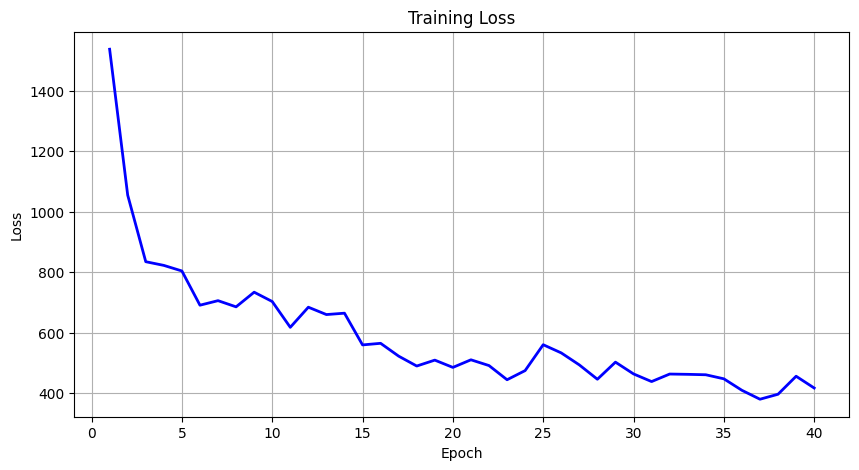

In [92]:
model = Sparse_RCNN(
    in_channel=1,
    out_channel=128,
    num_proposals=NUM_PROPOSALS,
    num_features=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    img_size=IMG_SIZE,
    num_iterations=NUM_ITERATIONS
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
matcher = HungarianMatcher(class_cost=2, bbox_cost=5)
criterion = LossCriterion(num_classes=NUM_CLASSES, matcher=matcher, 
                         class_weight=2.0, bbox_weight=5.0)

num_epochs = 40
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    
    for images, targets in train_loader:
        images = images.to(device)
        class_logits, pred_boxes = model(images)
        outputs = {'pred_logits': class_logits, 'pred_boxes': pred_boxes}
        loss_dict = criterion(outputs, targets)
        loss = loss_dict['loss_total']
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')


plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs+1), train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [ ]:
from torchvision.ops import box_iou

def calculate_iou(box1, box2):
    box1_tensor = torch.tensor([box1], dtype=torch.float32)
    box2_tensor = torch.tensor([box2], dtype=torch.float32)
    iou_value = box_iou(box1_tensor, box2_tensor).item()
    return iou_value

def calculate_ap(predictions, targets, iou_threshold=0.5):
    if len(predictions) == 0:
        return 0.0 if len(targets) > 0 else 1.0
    
    predictions = sorted(predictions, key=lambda x: x['score'], reverse=True)
   
    tp = np.zeros(len(predictions))
    fp = np.zeros(len(predictions))
    matched_targets = set()
    
    for i, pred in enumerate(predictions):
        best_iou = 0
        best_j = -1
        
        for j, target in enumerate(targets):
            if j in matched_targets:
                continue
            iou = calculate_iou(pred['box'], target['box'])
            if iou > best_iou:
                best_iou = iou
                best_j = j
        
        if best_iou >= iou_threshold:
            tp[i] = 1
            matched_targets.add(best_j)
        else:
            fp[i] = 1
    
    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)
    recalls = tp_cumsum / len(targets) if len(targets) > 0 else np.zeros_like(tp_cumsum)
    precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
    
    ap = 0
    for t in np.arange(0, 1.1, 0.1):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p / 11
    
    return ap

In [94]:

def convert_xywh_to_xyxy(boxes, img_size):
    x, y, w, h = boxes
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(img_size, x + w)
    y2 = min(img_size, y + h)
    return [x1, y1, x2, y2] if x2 > x1 and y2 > y1 else None


def extract_valid_predictions(class_probs, pred_boxes, confidence_threshold=0.3):
    valid_predictions = []
    
    for probs, box in zip(class_probs, pred_boxes):
        max_score = np.max(probs[1:])
        pred_class = np.argmax(probs[1:]) + 1
        
        if max_score > confidence_threshold:
            converted_box = convert_xywh_to_xyxy(box, IMG_SIZE)
            if converted_box is not None:
                valid_predictions.append({
                    'box': converted_box,
                    'score': max_score,
                    'class': pred_class
                })
    
    return valid_predictions

def extract_ground_truth(targets):
    ground_truths = []
    
    for target in targets:
        box = target['boxes'].numpy()
        converted_box = convert_xywh_to_xyxy(box, IMG_SIZE)
        if converted_box is not None:
            ground_truths.append({
                'box': converted_box,
                'class': target['labels'].item()
            })
    
    return ground_truths

In [116]:
model.eval()

all_predictions = {class_id: [] for class_id in range(1, 4)}
all_targets = {class_id: [] for class_id in range(1, 4)}

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        class_logits, pred_boxes = model(images)
        
        class_probs = F.softmax(class_logits, dim=-1).cpu().numpy()
        pred_boxes_np = pred_boxes.cpu().numpy()
        
        for batch_idx in range(len(images)):
            valid_predictions = extract_valid_predictions(
                class_probs[batch_idx], 
                pred_boxes_np[batch_idx]
            )
            
            for pred in valid_predictions:
                all_predictions[pred['class']].append({
                    'box': pred['box'],
                    'score': pred['score']
                })
            
            ground_truths = extract_ground_truth(targets[batch_idx])
            for gt in ground_truths:
                all_targets[gt['class']].append({'box': gt['box']})


aps = {}
print("Average Precision per class:")
for class_id in range(1, 4):
    ap = calculate_ap(all_predictions[class_id], all_targets[class_id])
    aps[class_id] = ap
    print(f"  {CLASS_NAMES[class_id].capitalize():<10} : {ap:.4f}")

mAP = np.mean(list(aps.values()))
print(f"mAP : {mAP:.4f}")

Average Precision per class:
  Circle     : 0.6895
  Square     : 0.7571
  Triangle   : 0.7497
mAP : 0.7321


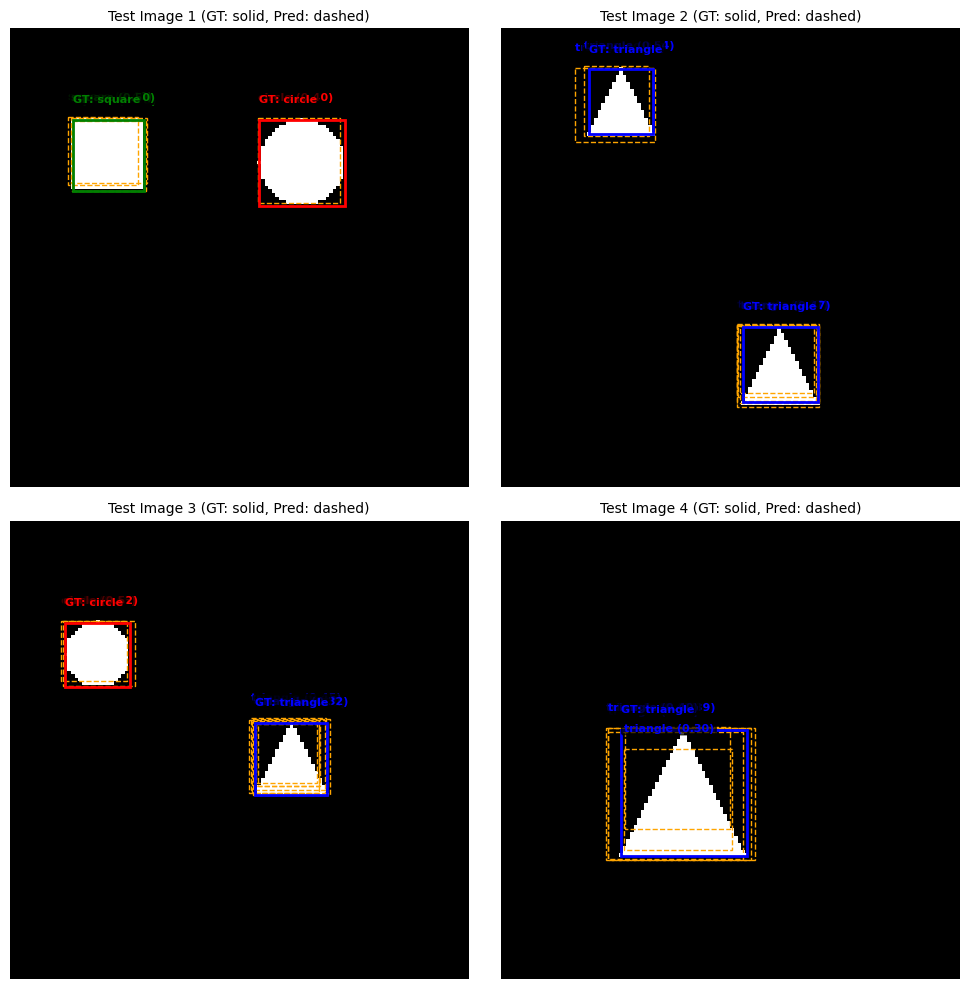

In [115]:
model.eval()

CONFIDENCE_THRESHOLD = 0.3

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

with torch.no_grad():
    for idx, (image, target) in enumerate(zip(X_test[10:14], y_test[10:14])):
        row = idx // 2
        col = idx % 2
        
        img_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        class_logits, pred_boxes = model(img_tensor)
        class_probs = F.softmax(class_logits, dim=-1).cpu().numpy()[0]
        pred_boxes_np = pred_boxes.cpu().numpy()[0]
        
        valid_predictions = extract_valid_predictions(class_probs, pred_boxes_np, CONFIDENCE_THRESHOLD)
        
        img_rgb = np.stack([image, image, image], axis=2)
        axes[row, col].imshow(img_rgb)

        for pred in valid_predictions:
            x1, y1, x2, y2 = pred['box']
            score = pred['score']
            pred_class = pred['class']
            
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=1, edgecolor="orange",
                facecolor='none', linestyle='--'
            )
            axes[row, col].add_patch(rect)
            axes[row, col].text(
                x1, y1-5, f"{CLASS_NAMES[pred_class]} ({score:.2f})",
                color=COLORS[pred_class], fontsize=8, weight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7)
            )
        
        for shape in target:
            x, y, w, h = shape['bbox']
            label = shape['label']
            
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=2, edgecolor=COLORS[label], facecolor='none'
            )
            axes[row, col].add_patch(rect)
            axes[row, col].text(
                x, y-5, f"GT: {CLASS_NAMES[label]}",
                color=COLORS[label], fontsize=8, weight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='black', alpha=0.7)
            )
        
        axes[row, col].set_title(f'Test Image {idx+1} (GT: solid, Pred: dashed)', fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

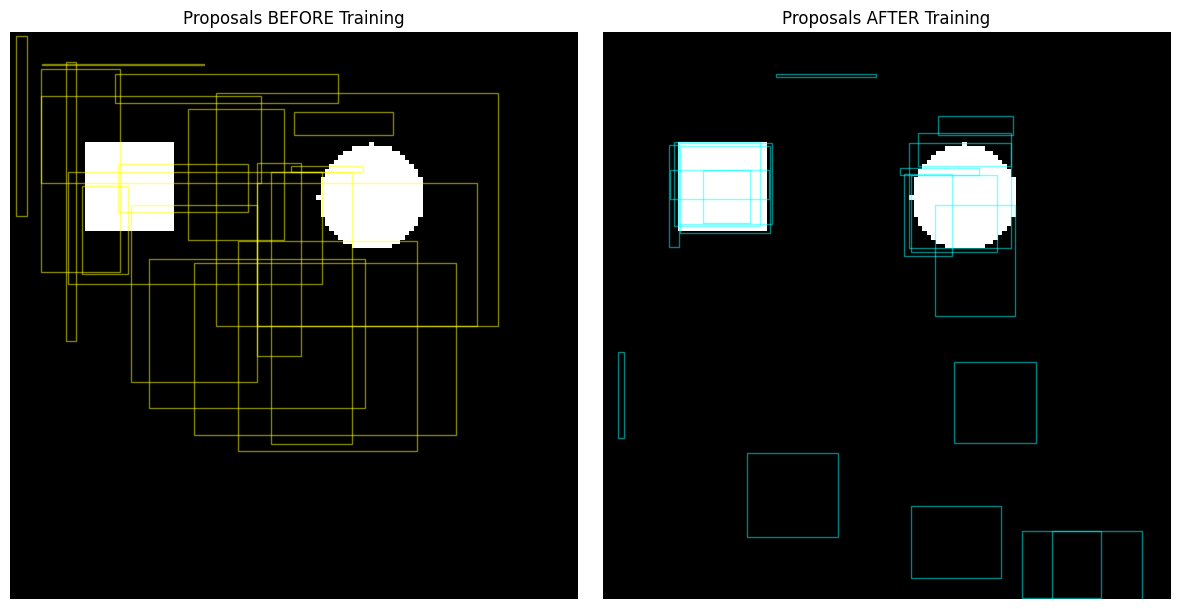

In [113]:
sample_image = torch.tensor(X_test[10], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    initial_boxes = model.proposal_boxes.cpu().numpy()
    _, final_boxes = model(sample_image)
    final_boxes = final_boxes.cpu().numpy()[0]

def draw_proposals(ax, boxes, title, color, alpha=0.5):
    img_display = np.stack([X_test[10], X_test[10], X_test[10]], axis=2)
    ax.imshow(img_display)
    
    for box in boxes:
        x, y, w, h = box
        x1 = max(0, min(x, IMG_SIZE))
        y1 = max(0, min(y, IMG_SIZE))
        x2 = min(IMG_SIZE, x + w)
        y2 = min(IMG_SIZE, y + h)
        
        if x2 > x1 and y2 > y1:
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=1, edgecolor=color, facecolor='none', alpha=alpha
            )
            ax.add_patch(rect)
    
    ax.set_title(title)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
draw_proposals(axes[0], initial_boxes, 'Proposals BEFORE Training', 'yellow', 0.5)
draw_proposals(axes[1], final_boxes, 'Proposals AFTER Training', 'cyan', 0.5)

plt.tight_layout()
plt.show()
